# XSS Detection in AI-Generated JavaScript

End-to-end pipeline for the final-year project.

**Stages:** dataset loading → tokenisation → TF-IDF features → train/test split
→ Logistic Regression + Random Forest → 5-fold cross-validation
→ Rule-based baseline → Semgrep → augmentation experiment
→ bootstrap CIs and McNemar tests → subpopulation analysis.

Random seed is fixed at 42 throughout for reproducibility.


## 1. Imports

In [9]:
# All third-party libraries used in the pipeline.
# pandas + numpy for tabular data and arrays.
# matplotlib for the confusion matrices and feature-importance bar charts.
# re for the regex-based tokeniser.
# scikit-learn for the vectoriser, the two classifiers, the train/test split

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import re
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedShuffleSplit, StratifiedKFold, cross_validate
from sklearn.metrics import (classification_report, confusion_matrix,
                             ConfusionMatrixDisplay, precision_recall_fscore_support)


ModuleNotFoundError: No module named 'pandas'

## 2. Load Dataset

The labelled dataset contains 250 JavaScript snippets across 18 task categories. Each row has a snippet, its task category, the label (1 = vulnerable, 0 = safe), and metadata fields used in error analysis.

In [ ]:
# Load the labelled CSV. Each row is one snippet with its category, code, and label.
df = pd.read_csv('./data/dataset_labelled.csv')

# Print a quick summary so we can confirm the dataset loaded correctly
# and check the class balance is roughly 50/50 (which is what we want).
print(f'Total snippets: {len(df)}')
print(f'Vulnerable: {df.label.sum()}')
print(f'Safe: {len(df) - df.label.sum()}')
print()

# Show the category breakdown so we can see how snippets are distributed.
# The lambda counts how many in each category have label 0 (safe).
print('Category breakdown:')
print(df.groupby('task_category')['label'].agg(['count','sum',lambda x:(x==0).sum()]).
      rename(columns={'count':'Total','sum':'Vulnerable','<lambda_0>':'Safe'}).
      sort_values('Total', ascending=False).to_string())


Total snippets: 250
Vulnerable: 124
Safe: 126

Category breakdown:
                                 Total  Vulnerable  Safe
task_category                                           
URL query parameter display         22          10    12
GitHub - real world                 22          11    11
Username welcome message            21          11    10
User comment rendering              20          10    10
Search term heading                 19           9    10
Form input live preview             18           9     9
Error message from URL hash         17           9     8
User profile card rendering         16           7     9
Referrer message display            15           7     8
Tag and filter display from URL     14           7     7
Dynamic link href from URL          12           6     6
Server response rendering           11           6     5
Image src from user input            9           4     5
LocalStorage data display            8           4     4
iframe content inject

## 3. Tokenisation and TF-IDF Features

JavaScript tokens like `innerHTML` and `location.search` carry security meaning. Standard tokenisers would split `location.search` into two tokens (`location` and `search`) which loses that meaning. So before tokenising, these compound tokens are joined with underscores so the regex keeps them as a single unit.

TF-IDF then converts each snippet into a numeric vector based on which tokens appear and how distinctive they are.

In [ ]:
# These are the tokens that carry security meaning.
# They include sinks (places where data ends up, like innerHTML),
# sources (places where untrusted data comes from, like location.search),
# and sanitisers (functions that make data safe, like DOMPurify).
# I want these treated as single tokens, not split on the dot.
SECURITY_TOKENS = [
    'innerHTML', 'outerHTML', 'document.write', 'document.writeln',
    'insertAdjacentHTML', 'dangerouslySetInnerHTML',
    'textContent', 'innerText', 'createTextNode',
    'DOMPurify', 'sanitize', 'encodeURIComponent',
    'location.search', 'location.hash', 'location.href',
    'document.referrer',
    'localStorage.getItem', 'sessionStorage.getItem',
    'setAttribute', 'addEventListener',
    'event.data'
]

def tokenise(code):
    # Step 1: replace dots inside compound tokens with underscores
    # so that "document.write" becomes "document_write" before regex.
    # This stops the regex below from splitting them in half.
    for token in SECURITY_TOKENS:
        code = code.replace(token, token.replace('.', '_'))
    # Step 2: pull out all the identifier-like tokens.
    # The regex matches anything that starts with a letter or underscore
    # and continues with letters, digits or underscores. This is what
    # JavaScript identifiers look like.
    tokens = re.findall(r'[a-zA-Z_][a-zA-Z0-9_]*', code)
    # Re-join with spaces so TfidfVectorizer treats them as words.
    return ' '.join(tokens)

# Apply the tokeniser to every snippet.
df['tokens'] = df['code'].apply(tokenise)

# TF-IDF turns the tokenised snippets into a numeric feature matrix.
# min_df=2 drops tokens that only appear in one snippet (they cannot
# generalise from one example). max_df=0.95 drops tokens that appear
# in more than 95% of snippets (they carry no discriminative signal).
# max_features=500 is a safety cap; the actual vocabulary turns out
# to be much smaller (around 176 tokens on this dataset).
vectoriser = TfidfVectorizer(min_df=2, max_df=0.95, max_features=500)
X = vectoriser.fit_transform(df['tokens'])
y = df['label'].values

# Confirm the feature matrix shape.
print(f'Feature matrix: {X.shape[0]} snippets x {X.shape[1]} tokens')


Feature matrix: 250 snippets x 176 tokens


## 4. Train/Test Split

An 80/20 split stratified by task category. Stratifying by category (rather than by label) keeps the same mix of task types in both train and test. The 20% test set is held back and never used during training.

`random_state=42` makes the split reproducible.

In [ ]:
# StratifiedShuffleSplit gives a 20% held-out test set with the same
# task-category proportions as the full dataset. We stratify by category
# rather than by label so the test set isn't accidentally dominated by
# one type of task (for example, only URL parameter snippets).
# Setting random_state=42 makes this split reproducible across runs.
sss = StratifiedShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_idx, test_idx = next(sss.split(X, df['task_category'].values))

# Slice the feature matrix and labels using those indices.
X_train, X_test = X[train_idx], X[test_idx]
y_train, y_test = y[train_idx], y[test_idx]

print(f'Train: {X_train.shape[0]} | Test: {X_test.shape[0]}')

# Sanity check: how many snippets from each category and label end up
# in the test set. Should be balanced and representative.
print(f'\nTest set categories:')
print(df.iloc[test_idx]['task_category'].value_counts().to_string())
print(f'\nTest set labels:')
print(df.iloc[test_idx]['label'].value_counts().to_string())


Train: 200 | Test: 50

Test set categories:
task_category
URL query parameter display        5
Username welcome message           4
GitHub - real world                4
Form input live preview            4
Search term heading                4
User comment rendering             4
Tag and filter display from URL    3
Error message from URL hash        3
User profile card rendering        3
Referrer message display           3
Dynamic link href from URL         2
LocalStorage data display          2
iframe content injection           2
Image src from user input          2
Server response rendering          2
PostMessage handler                1
Dynamic script execution           1
Inline event handler binding       1

Test set labels:
label
1    25
0    25


## 5. Logistic Regression

The first classifier. Logistic regression learns one weight per token; a snippet is flagged as vulnerable if the sum of the weights of its tokens (times their TF-IDF values) is positive.

`class_weight='balanced'` is a safety net in case the train/test split lands slightly uneven. The classes are nearly balanced (124 vs 126) so it makes almost no difference, but it doesn't hurt.

=== Logistic Regression ===
              precision    recall  f1-score   support

        Safe       0.86      1.00      0.93        25
  Vulnerable       1.00      0.84      0.91        25

    accuracy                           0.92        50
   macro avg       0.93      0.92      0.92        50
weighted avg       0.93      0.92      0.92        50



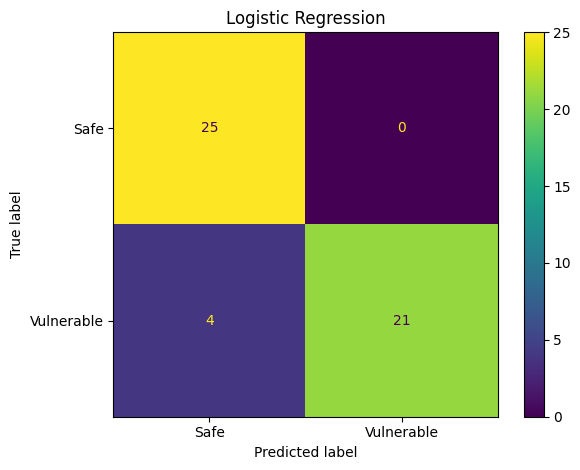

In [ ]:
# Train Logistic Regression on the 200 training snippets.
# class_weight='balanced' tells sklearn to weight rare-class errors
# more heavily; safe to keep even with balanced classes.
# max_iter=1000 just makes sure the optimiser has time to converge
# on this small dataset (default 100 is often not enough).
lr = LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)
lr.fit(X_train, y_train)

# Predict on the held-out 50 test snippets.
y_pred_lr = lr.predict(X_test)

# Print precision, recall and F1 for each class.
# F1 on the Vulnerable class is the headline metric (Section 5.3).
print('=== Logistic Regression ===')
print(classification_report(y_test, y_pred_lr, target_names=['Safe','Vulnerable']))

# Confusion matrix to make the TP/FN/TN/FP breakdown visible.
cm_lr = confusion_matrix(y_test, y_pred_lr)
ConfusionMatrixDisplay(cm_lr, display_labels=['Safe','Vulnerable']).plot()
plt.title('Logistic Regression')
plt.tight_layout()
plt.savefig('./data/cm_lr.png')
plt.show()


## 6. Random Forest

Same training data as LR, different algorithm. Random forest can capture interactions between tokens (e.g. "innerHTML is dangerous only when combined with location.search"). If the discriminative signal is largely additive (one token at a time is enough), LR and RF will perform similarly; if it's interaction-driven, RF will pull ahead.

=== Random Forest ===
              precision    recall  f1-score   support

        Safe       0.83      1.00      0.91        25
  Vulnerable       1.00      0.80      0.89        25

    accuracy                           0.90        50
   macro avg       0.92      0.90      0.90        50
weighted avg       0.92      0.90      0.90        50



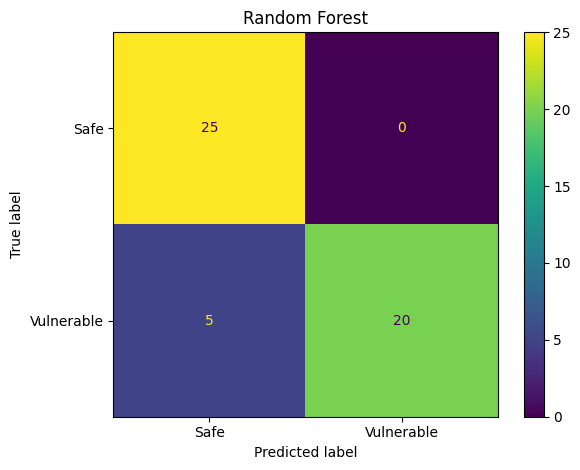

In [ ]:
# Random Forest with 100 trees. 100 is the standard default in scikit-learn
# and is the value used in most ML literature (Probst et al., 2019) because
# performance plateaus around there for most tasks.
# class_weight='balanced' for the same reason as LR.
rf = RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42)
rf.fit(X_train, y_train)

# Predict on the same held-out test set used for LR.
y_pred_rf = rf.predict(X_test)

print('=== Random Forest ===')
print(classification_report(y_test, y_pred_rf, target_names=['Safe','Vulnerable']))

cm_rf = confusion_matrix(y_test, y_pred_rf)
ConfusionMatrixDisplay(cm_rf, display_labels=['Safe','Vulnerable']).plot()
plt.title('Random Forest')
plt.tight_layout()
plt.savefig('./data/cm_rf.png')
plt.show()


## 7. 5-Fold Cross-Validation

A single train/test split can be lucky or unlucky. 5-fold CV splits the data five different ways and reports the mean +/- standard deviation, which is a more honest estimate of how the model would perform on unseen data.

=== 5-Fold Cross-Validation ===

Logistic Regression:
  Precision: 0.847 (+/- 0.078)
     Recall: 0.847 (+/- 0.068)
         F1: 0.843 (+/- 0.048)

Random Forest:
  Precision: 0.840 (+/- 0.046)
     Recall: 0.855 (+/- 0.086)
         F1: 0.843 (+/- 0.035)


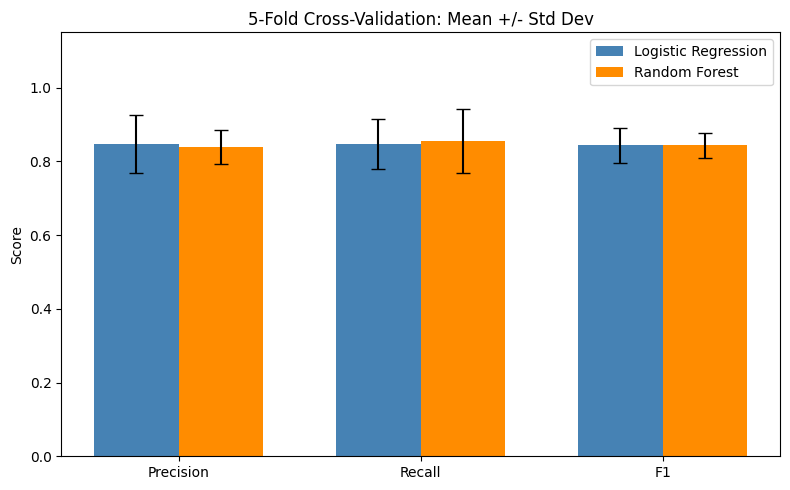

In [ ]:
# StratifiedKFold makes 5 folds, each preserving the class ratio.
# shuffle=True with a fixed seed mixes the data first, then splits.
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# cross_validate trains and evaluates the model on each fold automatically.
# We pass a fresh classifier each time (not the one we already trained)
# because cross_validate handles fitting internally.
lr_cv = cross_validate(
    LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42),
    X, y, cv=cv,
    scoring=['precision', 'recall', 'f1'],
    return_train_score=False
)

rf_cv = cross_validate(
    RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42),
    X, y, cv=cv,
    scoring=['precision', 'recall', 'f1'],
    return_train_score=False
)

# Print mean +/- std for each metric.
# The std tells us how stable the result is across folds.
print('=== 5-Fold Cross-Validation ===')
for name, res in [('Logistic Regression', lr_cv), ('Random Forest', rf_cv)]:
    print(f'\n{name}:')
    for metric in ['precision', 'recall', 'f1']:
        vals = res[f'test_{metric}']
        print(f'  {metric.capitalize():>9}: {vals.mean():.3f} (+/- {vals.std():.3f})')

# Plot the means with error bars for the std dev.
metrics = ['Precision', 'Recall', 'F1']
lr_means = [lr_cv[f'test_{m.lower()}'].mean() for m in metrics]
lr_stds  = [lr_cv[f'test_{m.lower()}'].std()  for m in metrics]
rf_means = [rf_cv[f'test_{m.lower()}'].mean() for m in metrics]
rf_stds  = [rf_cv[f'test_{m.lower()}'].std()  for m in metrics]

x = np.arange(len(metrics))
width = 0.35
fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(x - width/2, lr_means, width, yerr=lr_stds, label='Logistic Regression', capsize=5, color='steelblue')
ax.bar(x + width/2, rf_means, width, yerr=rf_stds, label='Random Forest', capsize=5, color='darkorange')
ax.set_ylim(0, 1.15)
ax.set_xticks(x)
ax.set_xticklabels(metrics)
ax.set_ylabel('Score')
ax.set_title('5-Fold Cross-Validation: Mean +/- Std Dev')
ax.legend()
plt.tight_layout()
plt.savefig('./data/cv_results.png')
plt.show()


## 8. Feature Importance

After training, each LR weight tells us how strongly the presence of that token pushes the prediction toward "vulnerable" (positive weight) or "safe" (negative weight). Inspecting the top-weighted tokens is a sanity check that the model is paying attention to semantically meaningful tokens like `innerHTML`, not surface noise.

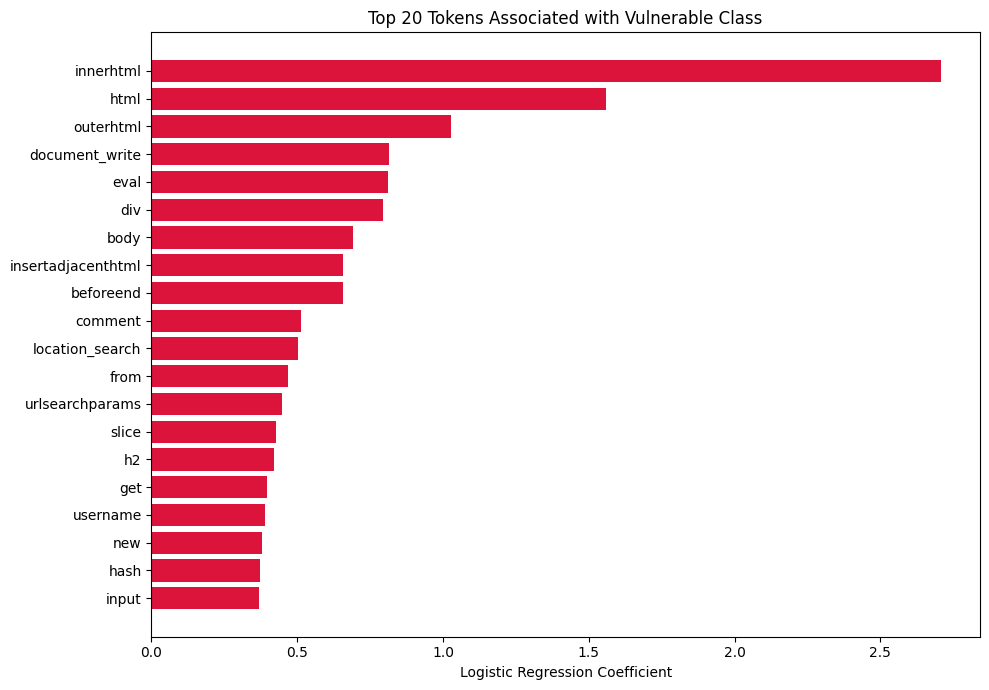

Top 10 tokens associated with VULNERABLE class:
  innerhtml: 2.7065
  html: 1.5605
  outerhtml: 1.0270
  document_write: 0.8138
  eval: 0.8130
  div: 0.7949
  body: 0.6917
  insertadjacenthtml: 0.6571
  beforeend: 0.6571
  comment: 0.5129

Top 10 tokens associated with SAFE class:
  innertext: -2.2381
  textcontent: -2.1998
  safe: -1.2335
  setattribute: -0.7864
  replace: -0.7192
  if: -0.6419
  getelementbyid: -0.6313
  com: -0.6274
  replacechildren: -0.6014
  https: -0.5638


In [ ]:
# Get the actual token strings in the order LR sees them.
feature_names = vectoriser.get_feature_names_out()
# coef_[0] is the array of weights, one per token.
# Positive weights push toward vulnerable, negative weights push toward safe.
coefs = lr.coef_[0]

# Sort indices by coefficient value. argsort gives ascending order;
# [-20:] takes the last 20 (the biggest); [::-1] reverses to descending.
top_idx = np.argsort(coefs)[-20:][::-1]
top_tokens = [feature_names[i] for i in top_idx]
top_weights = [coefs[i] for i in top_idx]

# Horizontal bar chart, reversed so highest weight is at the top.
plt.figure(figsize=(10, 7))
plt.barh(top_tokens[::-1], top_weights[::-1], color='crimson')
plt.xlabel('Logistic Regression Coefficient')
plt.title('Top 20 Tokens Associated with Vulnerable Class')
plt.tight_layout()
plt.savefig('./data/feature_importance.png')
plt.show()

# Also print the top 10 each way, for the dissertation.
print('Top 10 tokens associated with VULNERABLE class:')
for t, w in zip(top_tokens[:10], top_weights[:10]):
    print(f'  {t}: {w:.4f}')

bot_idx = np.argsort(coefs)[:10]
bot_tokens = [feature_names[i] for i in bot_idx]
bot_weights = [coefs[i] for i in bot_idx]

print('\nTop 10 tokens associated with SAFE class:')
for t, w in zip(bot_tokens[:10], bot_weights[:10]):
    print(f'  {t}: {w:.4f}')


## 9. Rule-Based Baseline

A simple proximity rule that simulates what a basic linter does: if a known dangerous sink (like `innerHTML`) appears within 80 characters of a known user-controlled source (like `location.search`), flag the snippet as vulnerable. If a sanitiser (like `DOMPurify`) appears anywhere, assume safe.

This is the comparator for RQ2 (does ML beat a rule-based approach?). The 80-character window was chosen because a sensitivity sweep at 40/80/120/160/240/320 showed F1 climbs steeply to 80 and then plateaus.

=== Rule-Based Baseline ===
              precision    recall  f1-score   support

        Safe       0.74      1.00      0.85        25
  Vulnerable       1.00      0.64      0.78        25

    accuracy                           0.82        50
   macro avg       0.87      0.82      0.81        50
weighted avg       0.87      0.82      0.81        50



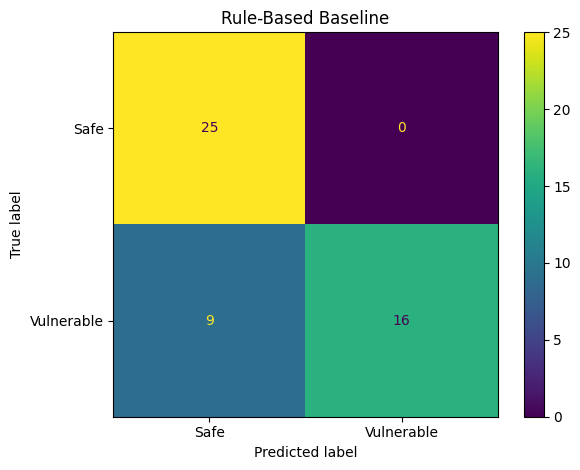

In [ ]:
# The three lists below are hardcoded sets of tokens that the rule
# checks for. UNSAFE_SINKS are places where untrusted data can become
# executable; SOURCES are places untrusted data comes from; SANITISERS
# are functions that make data safe.
UNSAFE_SINKS = [
    'innerHTML', 'outerHTML', 'document.write', 'document.writeln',
    'insertAdjacentHTML',
]

SOURCES = [
    'location.search', 'location.hash', 'location.href',
    'document.referrer', '.value', 'props.',
]

SANITISERS = [
    'DOMPurify', 'sanitize', 'createTextNode',
    'textContent', 'innerText',
]

def rule_baseline(code):
    # Rule 1: if any sanitiser appears anywhere in the code, treat as safe.
    # This is a conservative shortcut; the rule does not check that the
    # sanitiser is actually applied to the data flowing into the sink.
    if any(s in code for s in SANITISERS):
        return 0
    # Rule 2: walk through every occurrence of every sink, and check
    # if any source token appears within 80 characters either side.
    # If so, flag vulnerable.
    for sink in UNSAFE_SINKS:
        idx = code.find(sink)
        while idx != -1:
            window = code[max(0, idx-120):idx+120]
            if any(src in window for src in SOURCES):
                return 1
            # find the next occurrence of this sink (in case there are several)
            idx = code.find(sink, idx+1)
    # If no source-sink pair was found and no sanitiser blocked us, assume safe.
    return 0

# Run the rule on every test snippet.
test_df_baseline = df.iloc[test_idx].copy()
baseline_preds = [rule_baseline(row['code']) for _, row in test_df_baseline.iterrows()]

print('=== Rule-Based Baseline ===')
print(classification_report(y_test, baseline_preds, target_names=['Safe','Vulnerable']))

cm_bl = confusion_matrix(y_test, baseline_preds)
ConfusionMatrixDisplay(cm_bl, display_labels=['Safe','Vulnerable']).plot()
plt.title('Rule-Based Baseline')
plt.tight_layout()
plt.savefig('./data/cm_rule.png')
plt.show()


## 10. Export Test Snippets for Semgrep

Semgrep operates on actual `.js` files on disk, not in-memory strings. So before running Semgrep, write each of the 50 held-out test snippets to its own `.js` file. The filename includes the original snippet_id so we can map Semgrep's findings back to the right snippet.

In [ ]:
# Write each test snippet to its own .js file inside data/test_snippets/.
# The filename embeds the row index (so order is preserved) and the
# snippet_id (so we can recognise each one).
import os
os.makedirs('./data/test_snippets', exist_ok=True)
for i, row in df.iloc[test_idx].reset_index(drop=True).iterrows():
    fname = f'test_{i:03d}_{row["snippet_id"]}.js'
    with open(f'./data/test_snippets/{fname}', 'w') as f:
        f.write(row['code'])
print(f'Wrote {len(test_idx)} test snippets to ./data/test_snippets/')


Wrote 50 test snippets to ./data/test_snippets/


## 11. Run Semgrep and Parse Output

Now run Semgrep from the terminal (not from inside the notebook):

```bash
semgrep --config xss.yml data/test_snippets/ --json --quiet > data/semgrep_output.json
```

Semgrep version 1.162.0 was used. The YAML rules file `xss.yml` is included in the project root.

This cell then reads the JSON file Semgrep produced and converts it into a predictions list aligned with the test set order, so it can be compared directly to LR, RF and the rule baseline.

=== Semgrep ===
              precision    recall  f1-score   support

        Safe       0.92      0.96      0.94        25
  Vulnerable       0.96      0.92      0.94        25

    accuracy                           0.94        50
   macro avg       0.94      0.94      0.94        50
weighted avg       0.94      0.94      0.94        50



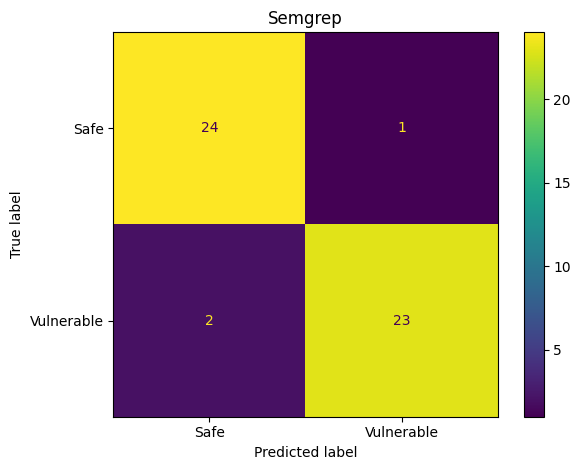

In [ ]:
import json

# Read the JSON file Semgrep produced from the command line.
with open('./data/semgrep_output.json') as f:
    sg = json.load(f)

# Semgrep's "results" array lists every rule firing. The "path" field
# tells us which file each finding came from. We only care whether
# each test file had ANY finding (not how many), so we collect just
# the unique filenames into a set.
flagged = set()
for r in sg['results']:
    fname = os.path.basename(r['path'])  # strip directory part
    flagged.add(fname)

# Walk through the test snippets in their original order and check
# whether each one's filename appears in the flagged set.
# Append 1 if Semgrep flagged it, 0 otherwise. This gives us a
# predictions list aligned to y_test for direct comparison.
y_pred_semgrep = []
for i, row in df.iloc[test_idx].reset_index(drop=True).iterrows():
    fname = f'test_{i:03d}_{row["snippet_id"]}.js'
    y_pred_semgrep.append(1 if fname in flagged else 0)

print('=== Semgrep ===')
print(classification_report(y_test, y_pred_semgrep, target_names=['Safe','Vulnerable']))

cm_semgrep = confusion_matrix(y_test, y_pred_semgrep)
ConfusionMatrixDisplay(cm_semgrep, display_labels=['Safe','Vulnerable']).plot()
plt.title('Semgrep')
plt.tight_layout()
plt.savefig('./data/cm_semgrep.png')
plt.show()


## 12. Side-by-Side Comparison

A single table comparing all four approaches on the held-out test set: LR, RF, the rule baseline, and Semgrep. F1 on the vulnerable class is the headline metric throughout the dissertation.

                     Precision  Recall     F1
Logistic Regression      1.000    0.84  0.913
Random Forest            1.000    0.80  0.889
Rule-Based Baseline      1.000    0.64  0.780
Semgrep                  0.958    0.92  0.939


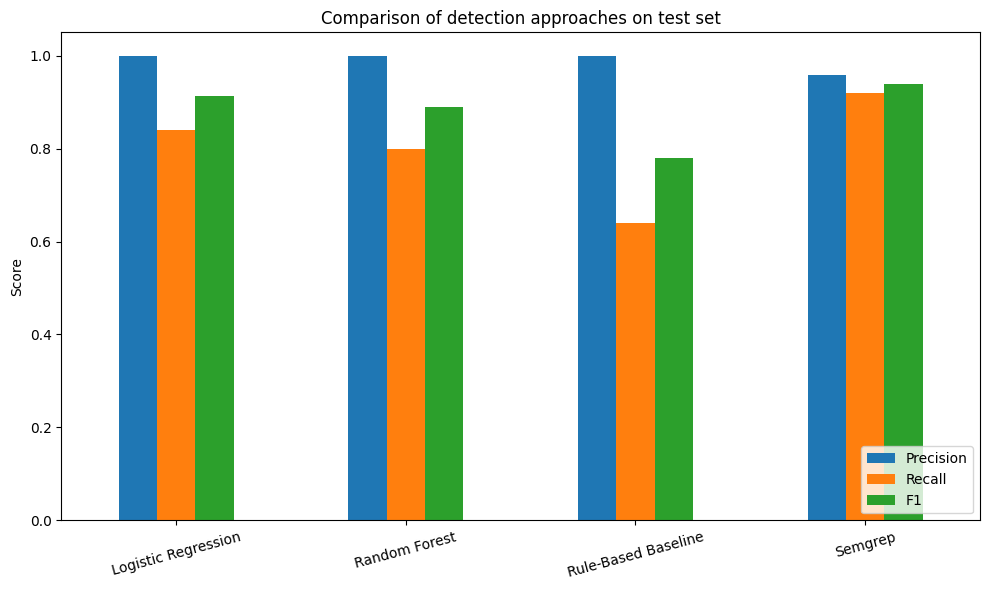

In [ ]:
def get_metrics(y_true, y_pred):
    # Compute precision, recall and F1 on the vulnerable class.
    # average='binary' tells sklearn to focus on the positive class (1).
    p, r, f, _ = precision_recall_fscore_support(y_true, y_pred, average='binary')
    return {'Precision': round(p, 3), 'Recall': round(r, 3), 'F1': round(f, 3)}

# Build a DataFrame with one row per approach and one column per metric.
# .T transposes it so approaches go down the rows (easier to read).
results = pd.DataFrame({
    'Logistic Regression': get_metrics(y_test, y_pred_lr),
    'Random Forest': get_metrics(y_test, y_pred_rf),
    'Rule-Based Baseline': get_metrics(y_test, baseline_preds),
    'Semgrep': get_metrics(y_test, y_pred_semgrep)
}).T

print(results)

# Grouped bar chart so the differences are visible at a glance.
ax = results.plot(kind='bar', figsize=(10, 6), rot=15)
plt.title('Comparison of detection approaches on test set')
plt.ylabel('Score')
plt.ylim(0, 1.05)
plt.legend(loc='lower right')
plt.tight_layout()
plt.savefig('./data/comparison.png')
plt.show()


## 13. Disagreement Analysis: ML vs Rule

On test snippets where the ML model and the rule baseline disagree, who is right? This is what Section 5.6 of the dissertation analyses. Each disagreement is broken down into "ML correct, baseline wrong" and "baseline correct, ML wrong", and the snippet IDs are listed for the case-by-case discussion.

In [ ]:
# Pick whichever ML model had the higher F1 as the representative.
best_preds = y_pred_lr if results.loc['Logistic Regression','F1'] >= results.loc['Random Forest','F1'] else y_pred_rf

# Make a copy of the test snippets table with three new columns:
# the ground truth label, the ML prediction, and the rule baseline prediction.
test_df = df.iloc[test_idx].copy()
test_df['ground_truth'] = y_test
test_df['ml_prediction'] = best_preds
test_df['baseline_prediction'] = baseline_preds

# Filter to only the rows where ML and rule disagree.
disagreements = test_df[test_df['ml_prediction'] != test_df['baseline_prediction']]
print(f'Total disagreements: {len(disagreements)}')

# Split disagreements into "ML wins" (ML correct, rule wrong)
# and "rule wins" (rule correct, ML wrong).
ml_wins = disagreements[(disagreements['ml_prediction'] == disagreements['ground_truth']) &
                        (disagreements['baseline_prediction'] != disagreements['ground_truth'])]
bl_wins = disagreements[(disagreements['baseline_prediction'] == disagreements['ground_truth']) &
                        (disagreements['ml_prediction'] != disagreements['ground_truth'])]

print(f'ML correct, baseline wrong: {len(ml_wins)}')
print(f'Baseline correct, ML wrong: {len(bl_wins)}')
print()

# Show the disagreement table so the dissertation can reference specific snippets.
disagreements[['snippet_id','task_category','ml_prediction','baseline_prediction','ground_truth','sink']]


Total disagreements: 9
ML correct, baseline wrong: 7
Baseline correct, ML wrong: 2



,snippet_id,task_category,ml_prediction,baseline_prediction,ground_truth,sink
182,snippet_260,GitHub - real world,1,0,1,DANGEROUS:jQuery.html()
143,snippet_221,Form input live preview,1,0,1,DANGEROUS:Function() constructor
208,snippet_286,iframe content injection,1,0,1,DANGEROUS:iframe.srcdoc
150,snippet_228,Username welcome message,1,0,1,DANGEROUS:setTimeout(string)
114,snippet_192,GitHub - real world,0,1,1,DANGEROUS:innerHTML
206,snippet_284,iframe content injection,1,0,1,DANGEROUS:iframe.srcdoc
222,snippet_300,Dynamic script execution,1,0,1,DANGEROUS:setTimeout(string)
107,snippet_185,GitHub - real world,0,1,1,DANGEROUS:innerHTML
226,snippet_304,Server response rendering,1,0,1,DANGEROUS:innerHTML


## 14. Data Augmentation Experiment (Section 4.8)

To test whether the small gap to Semgrep was caused by training-set scale rather than by a representational limit, the training set was expanded with semantically-equivalent variants of each snippet (rename generic variable names, swap `var` for `let`, swap quote style, prepend a benign comment). Each variant preserves the snippet's vulnerability label.

If augmentation closes the gap to Semgrep, the limit is data scale. If it doesn't, the limit is representation.

In [ ]:
import random
random.seed(42)
np.random.seed(42)

def augment_snippet(code):
    """Generate a few semantically-equivalent variants of one snippet.
    Each variant preserves the snippet's meaning and therefore its label."""
    variants = [code]  # the original is always included

    # Variant 1: rename common one-letter or generic identifiers to
    # more descriptive names. The regex \b ensures we match whole
    # tokens only (so 'var x' becomes 'var userInput', but 'var xyz' is untouched).
    renamed = code
    for pat, rep in [(r'\bvar\s+x\b', 'var userInput'),
                     (r'\bvar\s+y\b', 'var data'),
                     (r'\bvar\s+data\b', 'var payload'),
                     (r'\bvar\s+input\b', 'var userValue'),
                     (r'\blet\s+x\b', 'let param'),
                     (r'\bconst\s+x\b', 'const param'),
                     (r'\bvar\s+el\b', 'var element'),
                     (r'\bvar\s+e\b', 'var evt')]:
        renamed = re.sub(pat, rep, renamed)
    if renamed != code:
        variants.append(renamed)

    # Variant 2: replace 'var' with 'let' wherever it appears.
    # Both keywords behave the same for our purposes.
    var_to_let = re.sub(r'\bvar\b', 'let', code)
    if var_to_let != code:
        variants.append(var_to_let)

    # Variant 3: swap single quotes for double quotes (or vice versa),
    # but only when only one style is present (so we don't accidentally
    # break a string that uses both).
    if "'" in code and '"' not in code:
        variants.append(code.replace("'", '"'))
    elif '"' in code and "'" not in code:
        variants.append(code.replace('"', "'"))

    # Variant 4: prepend a benign comment line. The comment is ignored
    # by JavaScript at runtime but adds new tokens for TF-IDF.
    variants.append('// handle user-controlled input\n' + code)

    return variants

# Apply the augmentation to every training snippet, collect all variants.
train_code = df.iloc[train_idx]['code'].tolist()
train_labels = y_train.tolist()
aug_code, aug_labels = [], []
for code, label in zip(train_code, train_labels):
    for v in augment_snippet(code):
        aug_code.append(v)
        aug_labels.append(label)

# Deduplicate exact duplicates that the variants may produce
# (e.g. a snippet with no 'var' keyword would produce the same string twice).
seen = set()
dedup_code, dedup_labels = [], []
for c, l in zip(aug_code, aug_labels):
    if c not in seen:
        seen.add(c)
        dedup_code.append(c)
        dedup_labels.append(l)

print('=== AUGMENTATION ===')
print(f'Original training set: {len(train_code)} snippets')
print(f'Augmented training set: {len(dedup_code)} snippets')
print(f'Expansion factor: {len(dedup_code)/len(train_code):.2f}x')
print(f'Class balance: {sum(dedup_labels)} vulnerable, {len(dedup_labels)-sum(dedup_labels)} safe')

# Re-tokenise the augmented training data and rebuild the TF-IDF matrix.
# The vectoriser must be refit because the vocabulary may have grown.
aug_tokens = [tokenise(c) for c in dedup_code]
vectoriser_aug = TfidfVectorizer(min_df=2, max_df=0.95, max_features=500)
X_train_aug = vectoriser_aug.fit_transform(aug_tokens)

# Transform the test set using the AUGMENTED vectoriser so the feature
# spaces line up. The test set itself is left unchanged.
test_tokens = [tokenise(c) for c in df.iloc[test_idx]['code']]
X_test_aug = vectoriser_aug.transform(test_tokens)
print(f'Augmented feature matrix: {X_train_aug.shape[0]} x {X_train_aug.shape[1]} tokens')

# Retrain LR and RF on the augmented data with the same hyperparameters.
lr_aug = LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)
lr_aug.fit(X_train_aug, dedup_labels)
y_pred_lr_aug = lr_aug.predict(X_test_aug)

rf_aug = RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42)
rf_aug.fit(X_train_aug, dedup_labels)
y_pred_rf_aug = rf_aug.predict(X_test_aug)

# Compare F1 before and after augmentation. Negative delta means
# augmentation did not help; this is the project's null result and is
# itself a finding (limit is representational, not data-scale).
orig_lr_f1 = precision_recall_fscore_support(y_test, y_pred_lr, average='binary')[2]
aug_lr_f1 = precision_recall_fscore_support(y_test, y_pred_lr_aug, average='binary')[2]
orig_rf_f1 = precision_recall_fscore_support(y_test, y_pred_rf, average='binary')[2]
aug_rf_f1 = precision_recall_fscore_support(y_test, y_pred_rf_aug, average='binary')[2]
print(f'\nLR F1: {orig_lr_f1:.3f} -> {aug_lr_f1:.3f}  (delta {aug_lr_f1-orig_lr_f1:+.3f})')
print(f'RF F1: {orig_rf_f1:.3f} -> {aug_rf_f1:.3f}  (delta {aug_rf_f1-orig_rf_f1:+.3f})')


=== AUGMENTATION ===
Original training set: 200 snippets
Augmented training set: 612 snippets
Expansion factor: 3.06x
Class balance: 300 vulnerable, 312 safe
Augmented feature matrix: 612 x 446 tokens

LR F1: 0.913 -> 0.889  (delta -0.024)
RF F1: 0.889 -> 0.851  (delta -0.038)


## 15. Bootstrap 95% Confidence Intervals

The test set has only 50 snippets, so each F1 point estimate is sensitive to individual misclassifications. Bootstrap resampling re-runs the metric calculation on 1000 random resamples of the test set (with replacement) and reports the 2.5th and 97.5th percentiles. The resulting interval is what we can confidently say about the model's true F1.

In [ ]:
from sklearn.utils import resample

def bootstrap_f1_ci(y_true, y_pred, n=1000, seed=42):
    """Compute the 95% confidence interval on F1 via percentile bootstrap.

    The idea: build 1000 different "fake test sets" by resampling the real one
    with replacement, compute F1 on each, and look at the 2.5th and 97.5th
    percentiles of the resulting distribution. Those percentiles are the
    bounds of the 95% interval.
    """
    rng = np.random.RandomState(seed)
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    f1s = []
    for _ in range(n):
        # Sample with replacement from the test indices
        idx = rng.randint(0, len(y_true), size=len(y_true))
        # If the resample happens to have only one class, F1 is undefined; skip.
        if len(set(y_true[idx])) < 2:
            continue
        _, _, f1, _ = precision_recall_fscore_support(
            y_true[idx], y_pred[idx], average='binary', zero_division=0)
        f1s.append(f1)
    # Return the 2.5%/97.5% bounds and the mean of the distribution.
    return np.percentile(f1s, [2.5, 97.5]), np.mean(f1s)

print('=== BOOTSTRAP 95% CIs ON TEST-SET F1 (1000 resamples) ===')
for name, preds in [('LR', y_pred_lr), ('RF', y_pred_rf),
                    ('Rule', baseline_preds), ('Semgrep', y_pred_semgrep),
                    ('LR(aug)', y_pred_lr_aug), ('RF(aug)', y_pred_rf_aug)]:
    (lo, hi), mean = bootstrap_f1_ci(y_test, preds)
    print(f'  {name:10}: F1 CI [{lo:.3f}, {hi:.3f}]  bootstrap mean {mean:.3f}')


=== BOOTSTRAP 95% CIs ON TEST-SET F1 (1000 resamples) ===
  LR        : F1 CI [0.811, 0.982]  bootstrap mean 0.909
  RF        : F1 CI [0.766, 0.974]  bootstrap mean 0.885
  Rule      : F1 CI [0.622, 0.895]  bootstrap mean 0.771
  Semgrep   : F1 CI [0.851, 1.000]  bootstrap mean 0.936
  LR(aug)   : F1 CI [0.765, 0.976]  bootstrap mean 0.884
  RF(aug)   : F1 CI [0.722, 0.945]  bootstrap mean 0.843


## 16. McNemar's Exact Test on Paired Predictions

When two detectors are evaluated on the same test set, the differences in their predictions are paired (each snippet is seen by both). McNemar's test asks whether the disagreements between two detectors are symmetric (both detectors disagree equally often in either direction) or asymmetric (one detector is consistently right where the other is wrong).

A small p-value means the difference in error patterns is unlikely to be due to chance.

In [ ]:
# statsmodels has McNemar's implementation. Install on the fly if missing.
try:
    from statsmodels.stats.contingency_tables import mcnemar
except ImportError:
    import subprocess, sys
    subprocess.run([sys.executable, '-m', 'pip', 'install', '-q', 'statsmodels'])
    from statsmodels.stats.contingency_tables import mcnemar

def mcnemar_paired(y_true, pred_a, pred_b, name_a, name_b):
    """Run McNemar's exact test on the paired predictions of two detectors.

    Builds a 2x2 contingency table:
        n11 = both detectors right
        n10 = only A right (only B wrong)
        n01 = only B right (only A wrong)
        n00 = both detectors wrong

    McNemar's test compares n10 to n01. If they're roughly equal,
    the detectors disagree symmetrically (p large). If one is much
    bigger, one detector is systematically better (p small).
    """
    y_true = np.array(y_true)
    a = np.array(pred_a) == y_true  # array of booleans: is A right on each row?
    b = np.array(pred_b) == y_true  # same for B
    n11 = int(((a) & (b)).sum())
    n10 = int(((a) & (~b)).sum())
    n01 = int(((~a) & (b)).sum())
    n00 = int(((~a) & (~b)).sum())
    # exact=True uses the exact binomial test rather than chi-squared
    # approximation; appropriate when n10 + n01 is small.
    p = mcnemar([[n11, n10], [n01, n00]], exact=True).pvalue
    print(f'  {name_a:10} vs {name_b:10}: both right={n11}, only {name_a}={n10}, '
          f'only {name_b}={n01}, both wrong={n00}, p={p:.4f}')

print('=== McNEMAR EXACT TESTS ON PAIRED PREDICTIONS ===')
mcnemar_paired(y_test, y_pred_lr, baseline_preds, 'LR', 'Rule')
mcnemar_paired(y_test, y_pred_lr, y_pred_semgrep, 'LR', 'Semgrep')
mcnemar_paired(y_test, y_pred_semgrep, baseline_preds, 'Semgrep', 'Rule')
mcnemar_paired(y_test, y_pred_lr_aug, y_pred_lr, 'LR(aug)', 'LR(orig)')
mcnemar_paired(y_test, y_pred_lr, y_pred_rf, 'LR', 'RF')


=== McNEMAR EXACT TESTS ON PAIRED PREDICTIONS ===
  LR         vs Rule      : both right=39, only LR=7, only Rule=2, both wrong=2, p=0.1797
  LR         vs Semgrep   : both right=45, only LR=1, only Semgrep=2, both wrong=2, p=1.0000
  Semgrep    vs Rule      : both right=40, only Semgrep=7, only Rule=1, both wrong=2, p=0.0703
  LR(aug)    vs LR(orig)  : both right=45, only LR(aug)=0, only LR(orig)=1, both wrong=4, p=1.0000
  LR         vs RF        : both right=44, only LR=2, only RF=1, both wrong=3, p=1.0000


## 17. Subpopulation Analysis (Section 5.6.2)

The dataset includes one category, "GitHub - real world", whose snippets were generated to reproduce specific real-world patterns rather than via the same generic prompts as the other 17 categories. To make the methodological compromise visible, compute performance separately on each subpopulation.

In [ ]:
# Split the test set into two groups based on the task category.
test_df_sub = df.iloc[test_idx].reset_index(drop=True)
github_mask = (test_df_sub['task_category'] == 'GitHub - real world').values
prompt_mask = ~github_mask  # everything else (17 prompt-generated categories)

print(f'Prompt-generated test snippets: {prompt_mask.sum()}')
print(f'  Labels: {dict(zip(*np.unique(y_test[prompt_mask], return_counts=True)))}')
print(f'GitHub real-world test snippets: {github_mask.sum()}')
print(f'  Labels: {dict(zip(*np.unique(y_test[github_mask], return_counts=True)))}')

def subset_metrics(name, mask, predictors):
    """Print precision, recall and F1 for each detector on a subset of the test set."""
    print(f'\n=== {name} (n={mask.sum()}) ===')
    yt = y_test[mask]
    for pname, preds in predictors:
        yp = np.array(preds)[mask]
        # Edge case: if the subset has no positives, F1 is undefined.
        if sum(yt) == 0:
            tn = int(((yp == 0) & (yt == 0)).sum())
            fp = int(((yp == 1) & (yt == 0)).sum())
            print(f'  {pname:10}: no positives in subset (TN={tn}, FP={fp})')
            continue
        # Standard confusion-matrix counts on this subset.
        tp = int(((yp == 1) & (yt == 1)).sum())
        fn = int(((yp == 0) & (yt == 1)).sum())
        tn = int(((yp == 0) & (yt == 0)).sum())
        fp = int(((yp == 1) & (yt == 0)).sum())
        p, r, f, _ = precision_recall_fscore_support(yt, yp, average='binary', zero_division=0)
        print(f'  {pname:10}: TP={tp}, FN={fn}, TN={tn}, FP={fp}, P={p:.3f}, R={r:.3f}, F1={f:.3f}')

predictors = [('LR', y_pred_lr), ('RF', y_pred_rf),
              ('Rule', baseline_preds), ('Semgrep', y_pred_semgrep)]

subset_metrics('PROMPT-GENERATED ONLY', prompt_mask, predictors)
subset_metrics('GITHUB REAL-WORLD ONLY', github_mask, predictors)


Prompt-generated test snippets: 46
  Labels: {np.int64(0): np.int64(24), np.int64(1): np.int64(22)}
GitHub real-world test snippets: 4
  Labels: {np.int64(0): np.int64(1), np.int64(1): np.int64(3)}

=== PROMPT-GENERATED ONLY (n=46) ===
  LR        : TP=20, FN=2, TN=24, FP=0, P=1.000, R=0.909, F1=0.952
  RF        : TP=18, FN=4, TN=24, FP=0, P=1.000, R=0.818, F1=0.900
  Rule      : TP=14, FN=8, TN=24, FP=0, P=1.000, R=0.636, F1=0.778
  Semgrep   : TP=20, FN=2, TN=23, FP=1, P=0.952, R=0.909, F1=0.930

=== GITHUB REAL-WORLD ONLY (n=4) ===
  LR        : TP=1, FN=2, TN=1, FP=0, P=1.000, R=0.333, F1=0.500
  RF        : TP=2, FN=1, TN=1, FP=0, P=1.000, R=0.667, F1=0.800
  Rule      : TP=2, FN=1, TN=1, FP=0, P=1.000, R=0.667, F1=0.800
  Semgrep   : TP=3, FN=0, TN=1, FP=0, P=1.000, R=1.000, F1=1.000


## 18. Combination Detector + False-Negative Overlap

RQ3: does combining ML with Semgrep catch more vulnerable snippets than either alone? On this test set, the answer turns out to be no, because Semgrep catches a strict superset of what LR catches. That's not a failure of the combination idea; it's evidence that the two detectors share a representational blind spot for indirect-flow snippets (both miss the same two).

In [ ]:
# Combination rule: flag as vulnerable if EITHER LR or Semgrep flags it.
print('=== COMBINATION DETECTOR (LR OR Semgrep) ===')
y_pred_combo = [1 if (a or b) else 0 for a, b in zip(y_pred_lr, y_pred_semgrep)]
tp = sum(1 for t, p in zip(y_test, y_pred_combo) if t == 1 and p == 1)
fp = sum(1 for t, p in zip(y_test, y_pred_combo) if t == 0 and p == 1)
fn = sum(1 for t, p in zip(y_test, y_pred_combo) if t == 1 and p == 0)
print(f'  Caught {tp}/25 vulnerable; {fp} false positive(s), {fn} false negative(s)')
p, r, f, _ = precision_recall_fscore_support(y_test, y_pred_combo, average='binary')
print(f'  Combination: P={p:.3f}  R={r:.3f}  F1={f:.3f}')

# Inspect WHY the combination didn't add value: do LR and Semgrep
# fail on the same snippets or different ones?
print('\n=== FALSE-NEGATIVE OVERLAP ANALYSIS ==')
test_snippets = df.iloc[test_idx].reset_index(drop=True)
# Build sets of snippet_ids that each detector missed.
lr_fn = {test_snippets.iloc[i]['snippet_id'] for i, p in enumerate(y_pred_lr) if y_test[i]==1 and p==0}
sg_fn = {test_snippets.iloc[i]['snippet_id'] for i, p in enumerate(y_pred_semgrep) if y_test[i]==1 and p==0}
print(f'  LR false negatives: {sorted(lr_fn)}')
print(f'  Semgrep false negatives: {sorted(sg_fn)}')
# Set intersection: snippets missed by BOTH (the representational blind spot)
print(f'  Missed by both: {sorted(lr_fn & sg_fn)}')
# Set difference: snippets only LR misses (Semgrep saves these in the combination)
print(f'  Missed by LR only (Semgrep catches): {sorted(lr_fn - sg_fn)}')
# Set difference: snippets only Semgrep misses (LR saves these in the combination)
print(f'  Missed by Semgrep only (LR catches): {sorted(sg_fn - lr_fn)}')


=== COMBINATION DETECTOR (LR OR Semgrep) ===
  Caught 23/25 vulnerable; 1 false positive(s), 2 false negative(s)
  Combination: P=0.958  R=0.920  F1=0.939

=== FALSE-NEGATIVE OVERLAP ANALYSIS ==
  LR false negatives: ['snippet_185', 'snippet_192', 'snippet_269', 'snippet_306']
  Semgrep false negatives: ['snippet_269', 'snippet_306']
  Missed by both: ['snippet_269', 'snippet_306']
  Missed by LR only (Semgrep catches): ['snippet_185', 'snippet_192']
  Missed by Semgrep only (LR catches): []
